# Proyecto SQL: Análisis de Plataforma de Libros

**Objetivo:** Utilizar SQL para analizar el comportamiento de libros, autores, editoriales y usuarios con el fin de generar una propuesta de valor para un nuevo producto.

## 1. Objetivos del estudio

Los objetivos principales de este análisis son:

- Comprender la estructura y contenido de la base de datos proporcionada.
- Analizar el desempeño de libros, autores y editoriales.
- Evaluar el comportamiento y participación de los usuarios mediante calificaciones y reseñas.
- Obtener métricas clave que respalden decisiones de negocio para el desarrollo de un nuevo producto.

In [17]:
# import libraries
import pandas as pd
from sqlalchemy import create_engine

db_config = {
    'user': 'practicum_student', # username
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7', # password
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432, # connection port
    'db': 'data-analyst-final-project-db' # the name of the database
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# Conectarse a la base de datos
engine = create_engine(connection_string, connect_args={'sslmode':'require'})
import matplotlib.pyplot as plt

## 2. Exploración inicial de los datos

Se inspeccionan las primeras filas de cada tabla con el objetivo de comprender su estructura, tipos de datos y posibles relaciones.


In [26]:
queries = {
    "books": "SELECT * FROM books LIMIT 5;",
    "authors": "SELECT * FROM authors LIMIT 5;",
    "publishers": "SELECT * FROM publishers LIMIT 5;",
    "ratings": "SELECT * FROM ratings LIMIT 5;",
    "reviews": "SELECT * FROM reviews LIMIT 5;"
}

for name, q in queries.items():
    print(f"\nTabla: {name}")
    display(pd.read_sql(q, con=engine))



Tabla: books


,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268



Tabla: authors


,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd



Tabla: publishers


,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company



Tabla: ratings


,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2



Tabla: reviews


,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...


## 3. Desarrollo del análisis

### 3.1 Libros publicados después del 1 de enero de 2000

In [2]:
query = """
SELECT COUNT(book_id) AS books_after_2000
FROM books
WHERE publication_date > '2000-01-01';
"""

result = pd.read_sql(query, con=engine)
result

,books_after_2000
0,819


El análisis muestra que una proporción significativa del catálogo corresponde a libros publicados a partir del año 2000, lo que indica que la plataforma cuenta con una oferta amplia de contenido relativamente reciente. Este hallazgo es relevante para el diseño del producto, ya que permite priorizar recomendaciones, campañas de marketing y funcionalidades orientadas a lectores interesados en literatura contemporánea.

### 3.2 Reseñas y calificación promedio por libro

In [19]:
query = """
SELECT
    b.title,
    COUNT(DISTINCT rv.review_id) AS total_reviews,
    AVG(rt.rating) AS avg_rating
FROM books b
LEFT JOIN reviews rv ON b.book_id = rv.book_id
LEFT JOIN ratings rt ON b.book_id = rt.book_id
GROUP BY b.book_id, b.title;
"""
result = pd.read_sql(query, con=engine)
result


,title,total_reviews,avg_rating
0,'Salem's Lot,2,3.666667
1,1 000 Places to See Before You Die,1,2.500000
2,13 Little Blue Envelopes (Little Blue Envelope...,3,4.666667
3,1491: New Revelations of the Americas Before C...,2,4.500000
4,1776,4,4.000000
...,...,...,...
995,Wyrd Sisters (Discworld #6; Witches #2),3,3.666667
996,Xenocide (Ender's Saga #3),3,3.400000
997,Year of Wonders,4,3.200000
998,You Suck (A Love Story #2),2,4.500000


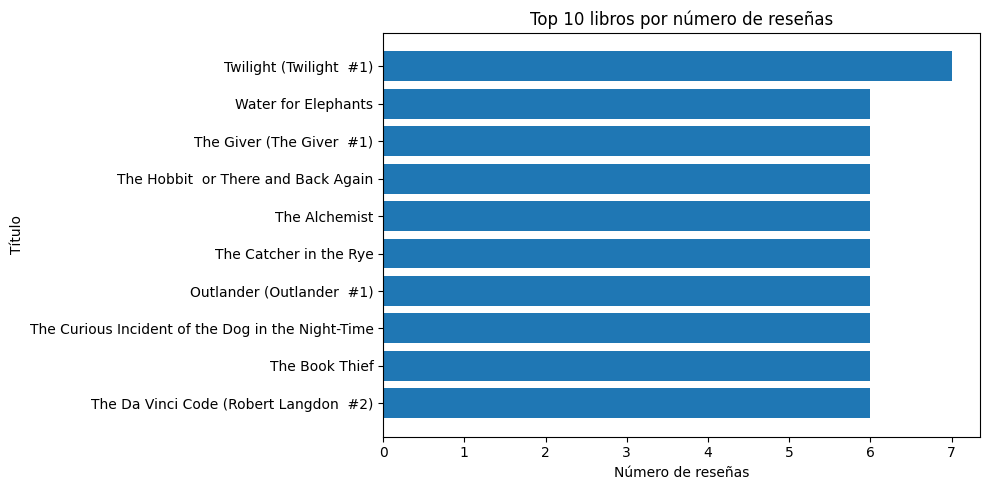

In [20]:
# Visualización: Top 10 libros por número de reseñas
top = result[['title', 'total_reviews']].sort_values('total_reviews', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top['title'][::-1], top['total_reviews'][::-1])
plt.xlabel('Número de reseñas')
plt.ylabel('Título')
plt.title('Top 10 libros por número de reseñas')
plt.tight_layout()
plt.show()


Se observa una alta concentración de reseñas en un conjunto reducido de libros, como se evidencia en la gráfica de los diez títulos con mayor número de reseñas. Esto sugiere la existencia de “libros ancla” que generan gran parte de la interacción de los usuarios. Estos títulos representan oportunidades estratégicas para promociones destacadas, sistemas de recomendación y generación de tráfico hacia otros contenidos relacionados.

### 3.3 Editorial con más libros de más de 50 páginas

In [21]:
query = """
SELECT
    p.publisher,
    COUNT(b.book_id) AS books_over_50_pages
FROM books b
JOIN publishers p ON b.publisher_id = p.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher_id, p.publisher
ORDER BY books_over_50_pages DESC;
"""

result = pd.read_sql(query, con=engine)
result.head(10)

,publisher,books_over_50_pages
0,Penguin Books,42
1,Vintage,31
2,Grand Central Publishing,25
3,Penguin Classics,24
4,Ballantine Books,19
5,Bantam,19
6,Berkley,17
7,Berkley Books,14
8,St. Martin's Press,14
9,William Morrow Paperbacks,13


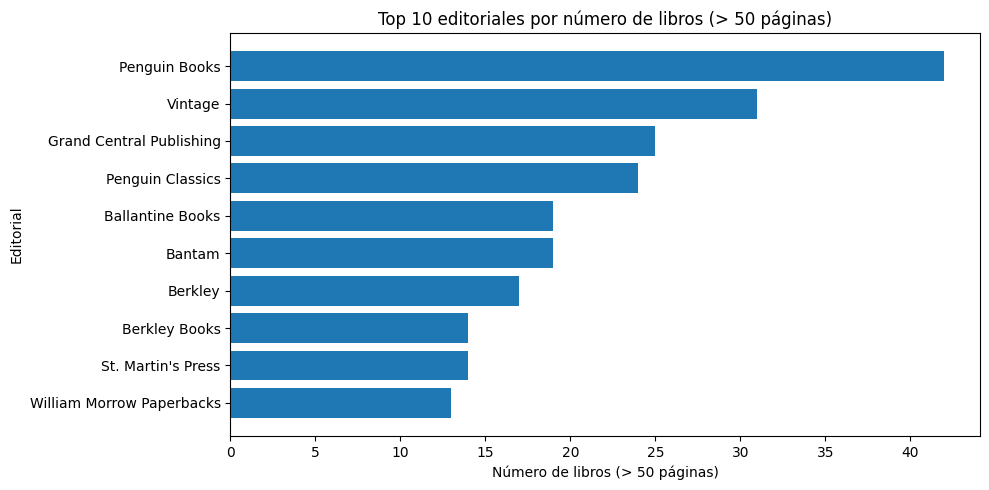

In [22]:
# Visualización: Top 10 editoriales por libros > 50 páginas
top_pub = result[['publisher', 'books_over_50_pages']].head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_pub['publisher'][::-1], top_pub['books_over_50_pages'][::-1])
plt.xlabel('Número de libros (> 50 páginas)')
plt.ylabel('Editorial')
plt.title('Top 10 editoriales por número de libros (> 50 páginas)')
plt.tight_layout()
plt.show()


El análisis identifica a un grupo reducido de editoriales que concentran la mayor cantidad de libros de más de 50 páginas, lo cual refleja una estructura de oferta dominada por pocos actores principales. Este resultado permite orientar negociaciones comerciales, alianzas estratégicas y priorización de catálogos con editoriales que aportan mayor volumen de contenido relevante para la plataforma.

### 3.4 Autor con mayor calificación promedio

In [15]:
query = """
WITH books_50_ratings AS (
    SELECT
        b.book_id,
        b.author_id,
        AVG(r.rating) AS book_avg_rating,
        COUNT(r.rating_id) AS n_ratings
    FROM books b
    JOIN ratings r ON b.book_id = r.book_id
    GROUP BY b.book_id, b.author_id
    HAVING COUNT(r.rating_id) >= 50
)
SELECT
    a.author,
    AVG(b50.book_avg_rating) AS avg_rating_author,
    COUNT(b50.book_id) AS books_considered
FROM books_50_ratings b50
JOIN authors a ON b50.author_id = a.author_id
GROUP BY a.author
ORDER BY avg_rating_author DESC
LIMIT 1;
"""

result = pd.read_sql(query, con=engine)
result

,author,avg_rating_author,books_considered
0,J.K. Rowling/Mary GrandPré,4.283844,4


Al filtrar únicamente libros con un volumen significativo de calificaciones, el análisis identifica al autor con la valoración promedio más alta de la plataforma. Este resultado ofrece un indicador confiable de calidad percibida por los usuarios, útil para campañas de promoción, curaduría de contenido premium y generación de recomendaciones personalizadas de alto impacto.

### 3.5 Promedio de reseñas entre usuarios activos

In [24]:
query = """
WITH users_50_ratings AS (
    SELECT
        username
    FROM ratings
    GROUP BY username
    HAVING COUNT(DISTINCT book_id) > 50
),
reviews_per_user AS (
    SELECT
        u.username,
        COUNT(rv.review_id) AS n_reviews
    FROM users_50_ratings u
    LEFT JOIN reviews rv ON u.username = rv.username
    GROUP BY u.username
)
SELECT
    username,
    n_reviews
FROM reviews_per_user
ORDER BY n_reviews DESC;
"""

per_user = pd.read_sql(query, con=engine)
avg_reviews = per_user["n_reviews"].mean()

print(f"Promedio de reseñas entre usuarios que calificaron >50 libros: {avg_reviews:.2f}")
per_user.head()


Promedio de reseñas entre usuarios que calificaron >50 libros: 24.33


,username,n_reviews
0,sfitzgerald,28
1,martinadam,27
2,richard89,26
3,jennifermiller,25
4,paul88,22


Los usuarios altamente activos (aquellos que calificaron más de 50 libros) presentan un nivel variable pero consistente de generación de reseñas de texto, como se observa en la distribución mostrada en el histograma. El promedio obtenido refleja un segmento de usuarios particularmente comprometido, cuya actividad resulta clave para la generación de contenido y la credibilidad del ecosistema de la plataforma.

## Conclusiones Finales

El análisis integral de la base de datos revela patrones claros de comportamiento tanto en la oferta de contenido como en la interacción de los usuarios. La plataforma depende de un conjunto concentrado de libros, autores y editoriales que generan la mayor parte de la actividad, mientras que un segmento reducido de usuarios altamente comprometidos impulsa la producción de reseñas y calificaciones.

Estos hallazgos permiten orientar el diseño de la propuesta de valor hacia tres ejes estratégicos: fortalecimiento de alianzas con editoriales clave, promoción de autores y títulos con alta valoración y desarrollo de funcionalidades centradas en usuarios de alto compromiso. En conjunto, los resultados proporcionan una base sólida para la toma de decisiones y el desarrollo de un producto competitivo dentro del mercado de lectura digital.
